In [17]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import lightgbm as lgb
import os
import pickle
from lightgbm import LGBMClassifier
from sklearn import metrics
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('../data/credit_risk_dataset_cleaned.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32574,57,53000,MORTGAGE,1,PERSONAL,C,5800,13.16,0,0.11,N,30
32575,54,120000,MORTGAGE,4,PERSONAL,A,17625,7.49,0,0.15,N,19
32576,65,76000,RENT,3,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32577,56,150000,MORTGAGE,5,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32579 entries, 0 to 32578
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32579 non-null  int64  
 1   person_income               32579 non-null  int64  
 2   person_home_ownership       32579 non-null  object 
 3   person_emp_length           32579 non-null  int64  
 4   loan_intent                 32579 non-null  object 
 5   loan_grade                  32579 non-null  object 
 6   loan_amnt                   32579 non-null  int64  
 7   loan_int_rate               32579 non-null  float64
 8   loan_status                 32579 non-null  int64  
 9   loan_percent_income         32579 non-null  float64
 10  cb_person_default_on_file   32579 non-null  object 
 11  cb_person_cred_hist_length  32579 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


In [4]:

cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "loan_status",
    "cb_person_default_on_file"
]

df["person_home_ownership"] = df["person_home_ownership"].astype('category')
df["loan_intent"] = df["loan_intent"].astype('category')
df["loan_grade"] = df["loan_grade"].astype('category')
df["loan_status"] = df["loan_status"].astype('category')
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].astype('category')

In [5]:
df["loan_status"] = df["loan_status"].astype(int)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32579 entries, 0 to 32578
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32579 non-null  int64   
 1   person_income               32579 non-null  int64   
 2   person_home_ownership       32579 non-null  category
 3   person_emp_length           32579 non-null  int64   
 4   loan_intent                 32579 non-null  category
 5   loan_grade                  32579 non-null  category
 6   loan_amnt                   32579 non-null  int64   
 7   loan_int_rate               32579 non-null  float64 
 8   loan_status                 32579 non-null  int64   
 9   loan_percent_income         32579 non-null  float64 
 10  cb_person_default_on_file   32579 non-null  category
 11  cb_person_cred_hist_length  32579 non-null  int64   
dtypes: category(4), float64(2), int64(6)
memory usage: 2.1 MB


In [7]:
x = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
# Create LightGBM datasets for training and testing
train_data = lgb.Dataset(x_train, label=y_train)
test_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

In [10]:
bst = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="rf",
    num_leaves=7,
    force_row_wise=True,
    learning_rate=0.01,
    metric="binary_logloss",
    bagging_fraction=0.8,
    feature_fraction=0.8,
    n_estimators=1000
)

# Fit model
bst.fit(x_train, y_train, eval_set=[(x_test, y_test)])

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 5682, number of negative: 20381
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 26063, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218010 -> initscore=-1.277300
[LightGBM] [Info] Start training from score -1.277300
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 

,boosting_type,'rf'
,num_leaves,7
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
# Make predictions
y_pred = bst.predict(x_test)

# Convert probabilities to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1score = f1_score(y_test, y_pred_binary)
# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1score:.4f}")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Accuracy: 0.9121
Precision: 0.9034
Recall: 0.6695
F1-Score: 0.7690


In [12]:
y_test

14447    1
24613    0
11096    0
10424    1
12628    0
        ..
13814    0
25288    0
2862     1
14753    0
14169    1
Name: loan_status, Length: 6516, dtype: int64

In [13]:
y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(6516,))

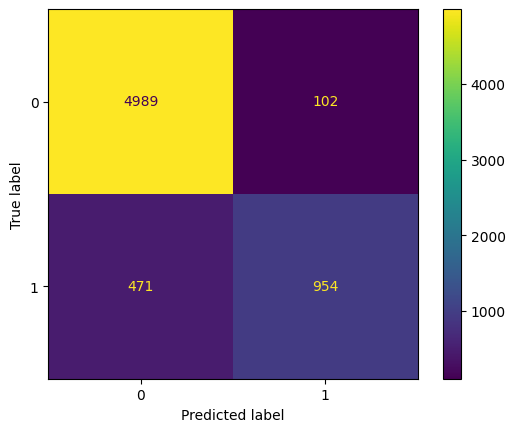

In [14]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

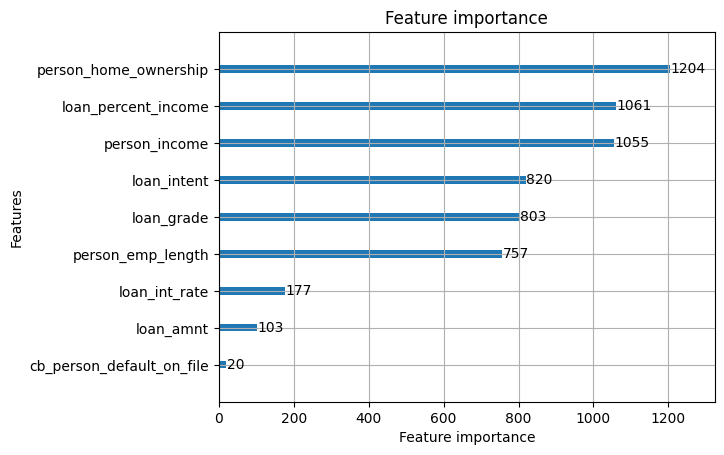

In [15]:
lgb.plot_importance(bst)

### Saving the model

In [19]:
save_dir = '../saved_model/'
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, "bst.pkl")
with open(file_path, 'wb') as f:
    pickle.dump(bst, f)